In [6]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_all_samples, save_cns_fig, load_merged_samples
from cns.utils.kneepoint import find_knee, count_cum_val

In [32]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [9]:
data = load_all_samples(False, False, False, True)
# rename key TCGA_hg19 to TCGA
data["TCGA"] = data["TCGA_hg19"]
del data["TCGA_hg19"]
data["combined"] = load_merged_samples(False, False, False)
datasets = list(data.keys())
print(datasets)
colors = {"PCAWG": "C0", "TCGA": "C1", "TRACERx": "C2", "combined": "gray"}

['PCAWG', 'TRACERx', 'TCGA', 'combined']


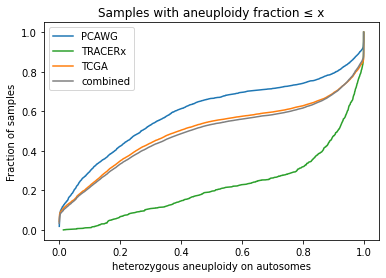

In [10]:
feature = "ane_het_aut"   
for k in datasets:
    X, Y = count_cum_val(data[k][feature])    
    plt.plot(X, Y, label=k, color=colors[k])    
    
plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

PCAWG 1828.9937888198758 152 51.533835835517195
TCGA 8289.909175162187 383 57.395817800299135
combined 10594.45671641791 498 54.94018054918765


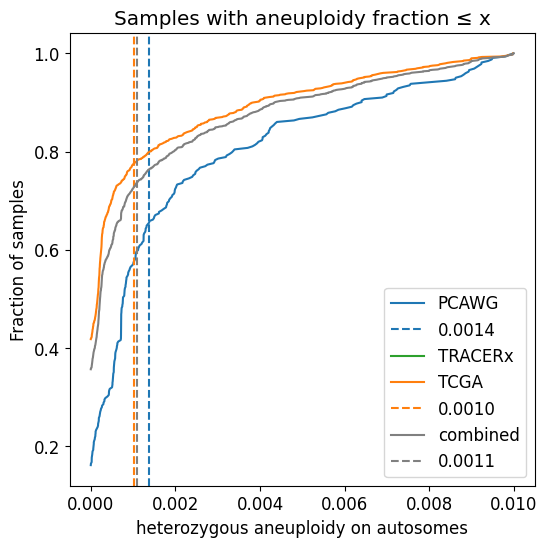

In [35]:
feature = "ane_het_aut"   
for k in datasets:
    X, Y = count_cum_val(data[k][feature], max_val=0.01)
    plt.plot(X, Y, label=k, color=colors[k])    
    knee_index, knee_value = find_knee(X, Y, knee=True)
    if knee_index < 0:
        continue
    sample_c = Y[knee_index] * len(data[k])
    print(k, sample_c, knee_index, knee_value)
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

PCAWG 28.01008282319049 27 81.1787477547012
PCAWG below sample_id
SP107557    0.576691
Name: cover_het_aut, dtype: float64
TRACERx 93.0 19 53.65939196452854
TCGA 209.0 197 59.26754794224968
combined 1936.1347438752782 830 77.92289252942847
combined below sample_id
SP107557    0.576691
Name: cover_het_aut, dtype: float64


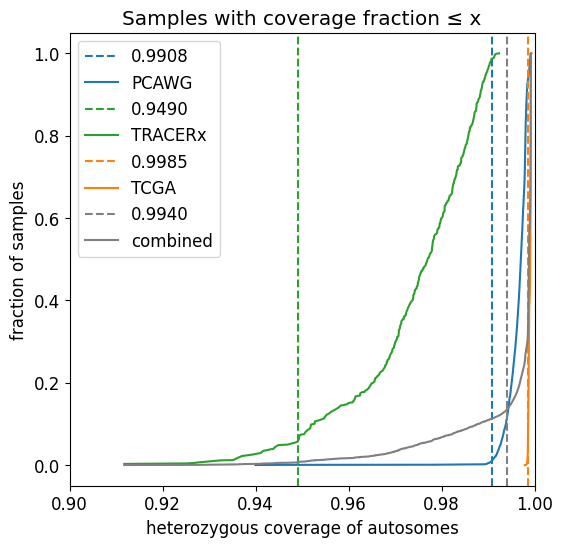

In [38]:
feature = "cover_het_aut"   
min_val = 0.90
for k in datasets:
    X, Y = count_cum_val(data[k][feature], min_val=min_val)
    below = data[k][feature][data[k][feature] < min_val]

    knee_index, knee_value = find_knee(X, Y, knee=False)
    if knee_index < 0:
        continue
    sample_c = Y[knee_index] * len(data[k])
    print(k, sample_c, knee_index, knee_value)
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

    if (len(below) > 0):
        print(k, "below", below)
    plt.plot(X, Y, label=k, color=colors[k])    

plt.xlim(min_val, 1)
plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
save_cns_fig(f"fig_samples_coverage_fraction_lim")

PCAWG 3
TRACERx 19
TCGA 17
combined 354


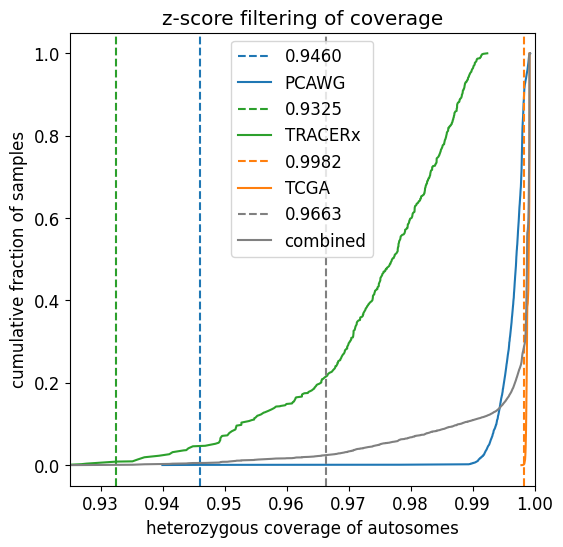

In [63]:
feature = "cover_het_aut"   
min_val = 0.925
outliers = {}
for k in datasets:
    X, Y = count_cum_val(data[k][feature], min_val=min_val)
    selection = data[k][feature]
    # calculate the z-score for selection
    z = (selection - selection.mean()) / selection.std()
    filter = z[(z < -3)]
    outliers[k] = data[k].loc[filter.index]
    print(k, len(outliers[k]))
    x_pos = outliers[k][feature].max()
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")
    plt.plot(X, Y, label=k, color=colors[k])   

plt.xlim(min_val, 1)
plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("cumulative fraction of samples")
plt.legend()
plt.title(f"z-score filtering of coverage")
save_cns_fig(f"fig_samples_coverage_fraction_lim")

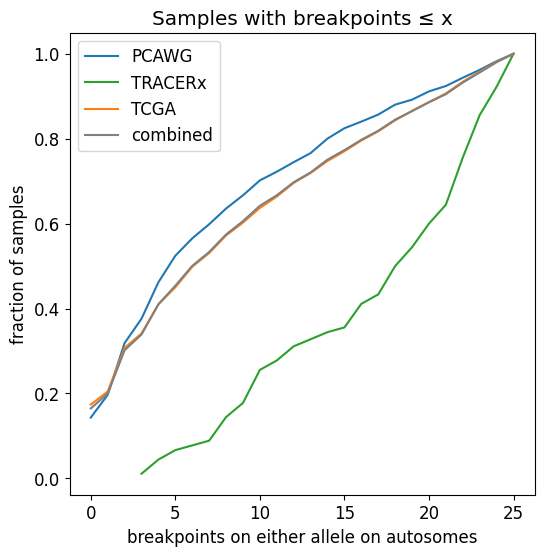

In [157]:
feature = "breaks_total_cn_aut"   
for k in datasets:
    X, Y = count_cum_val(data[k][feature], max_val=25)
    plt.plot(X, Y, label=k, color=colors[k])    

plt.ylabel("fraction of samples")
plt.xlabel("breakpoints on either allele on autosomes")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
save_cns_fig(f"fig_samples_breakpoints")

In [158]:
def plot_feature(feature, label, data, min_val=None, max_val=None):
    min_val = np.min([np.min(v[feature]) for v in data.values()]) if min_val is None else min_val
    max_val = np.max([np.max(v[feature]) for v in data.values()]) if max_val is None else max_val
    for k, v in data.items():
        X, Y = count_cum_val(v[feature], min_val, max_val)    
        plt.plot(X, Y, label=k, color=colors[k])    
        
    plt.xlabel(f"{label} value")
    plt.ylabel("fraction of samples")
    plt.legend()
    plt.title(f"Samples with {label} fraction ≤ x")    
    save_cns_fig(f"fig_samples_{feature}")

In [159]:
data["combined"].columns

Index(['sex', 'type', 'chrom_count', 'chrom_missing', 'cover_het_aut',
       'cover_het_sex', 'cover_het_all', 'cover_hom_aut', 'cover_hom_sex',
       'cover_hom_all', 'ane_hom_aut', 'ane_hom_sex', 'ane_hom_all',
       'ane_het_aut', 'ane_het_sex', 'ane_het_all', 'loh_hom_aut',
       'loh_hom_sex', 'loh_hom_all', 'loh_het_aut', 'loh_het_sex',
       'loh_het_all', 'imb_major_cn_aut', 'imb_major_cn_sex',
       'imb_major_cn_all', 'breaks_major_cn_aut', 'breaks_major_cn_sex',
       'breaks_major_cn_all', 'step_major_cn_aut', 'step_major_cn_sex',
       'step_major_cn_all', 'segsize_major_cn_aut', 'segsize_major_cn_sex',
       'segsize_major_cn_tot', 'breaks_minor_cn_aut', 'breaks_minor_cn_sex',
       'breaks_minor_cn_all', 'step_minor_cn_aut', 'step_minor_cn_sex',
       'step_minor_cn_all', 'segsize_minor_cn_aut', 'segsize_minor_cn_sex',
       'segsize_minor_cn_tot', 'breaks_total_cn_aut', 'breaks_total_cn_sex',
       'breaks_total_cn_all', 'step_total_cn_aut', 'step_total_cn_

Text(0.5, 18.825000000000003, 'total number of breakpoints')

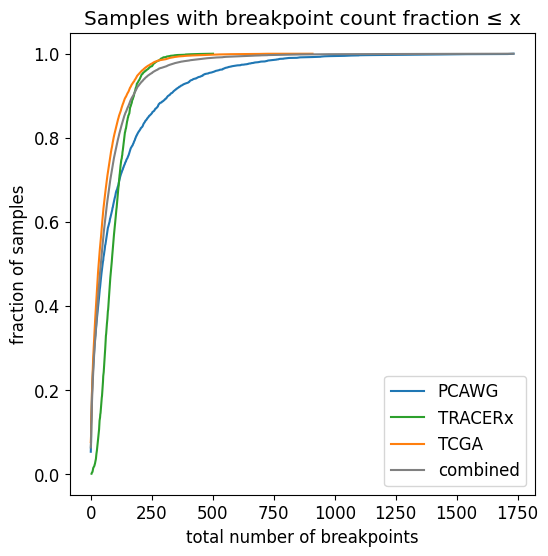

In [160]:
plot_feature("breaks_total_cn_aut", "breakpoint count", data)
plt.xlabel("total number of breakpoints")

Text(0.5, 18.825000000000003, 'heterozygous LOH on autosomes')

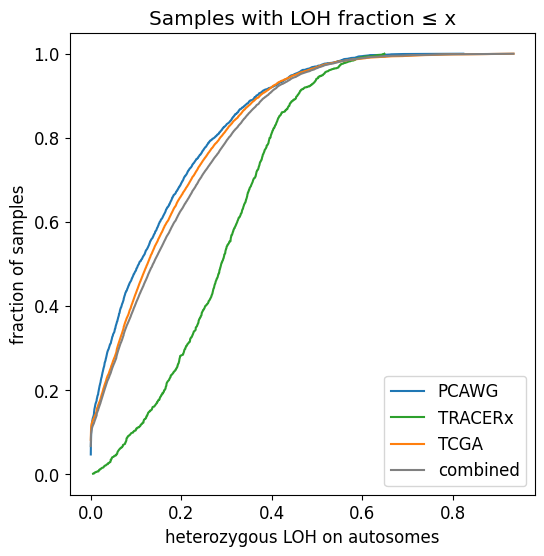

In [161]:
plot_feature("loh_het_aut", "LOH", data)
plt.xlabel("heterozygous LOH on autosomes")

Text(0.5, 18.825000000000003, 'Average step between breakpoints on autosomes')

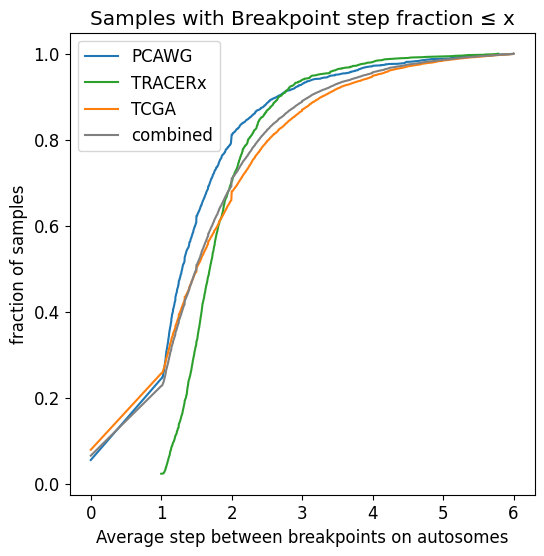

In [162]:
plot_feature("step_total_cn_aut", "Breakpoint step", data, max_val = 6)
plt.xlabel("Average step between breakpoints on autosomes")

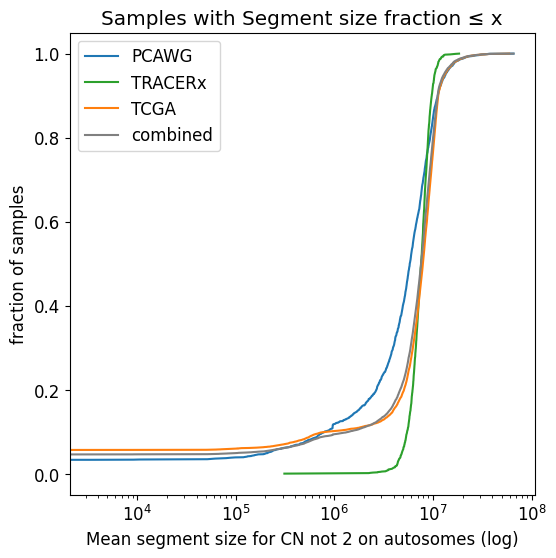

In [163]:
plot_feature("segsize_total_cn_aut", "Segment size", data)
plt.xlabel("Mean segment size for CN not 2 on autosomes (log)")
plt.xscale("log")